In [1]:
%load_ext autoreload
%autoreload 2
from NLSE import SingleRing
import numpy as np
import matplotlib.pyplot as plt

c = 299792458

wl_center = 1560e-9
omega_0 = 2 * np.pi * c / wl_center

neff = c / ( 630e-6 * 200e9 )

alpha = 0.0018
theta = 0.0005
alpha_int = 2 * alpha - theta

simulation = SingleRing(
    neff=neff, 
    FSR=200e9,
    coupling_ring_bus=0.0005,
    coupling_ring_drop=0,
    gamma=0.9,
    alpha_int=alpha_int,
    beta_2=-202e-27,
    omega_0=omega_0,
    n_small_time=512
)

detuning = 4.5 * simulation.alpha
intensity_in = simulation.S_2_Iin(np.sqrt(8.7))

A_in = -1j * np.sqrt(intensity_in) * np.ones(simulation.time.shape)
A_init = simulation.make_seed(detuning, intensity_in)

run_sim = simulation.get_ikeda_map()
A_main, A_out, A_drop = run_sim(A_init, A_in, detuning=detuning, nrt=10 / simulation.alpha, n_per_step=5)

In [2]:
beta_2 = simulation.beta_2
alpha_int = simulation.alpha_int
cavity_length = simulation.cavity_length
gamma = simulation.gamma
h = cavity_length
alpha = simulation.alpha
coupling_ring_bus = simulation.coupling_ring_bus

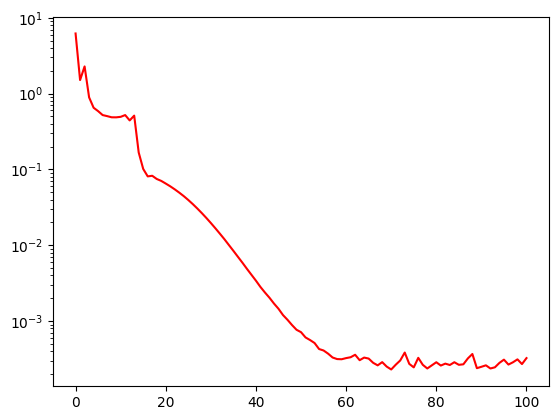

(-10.0, 6.394466805458069)

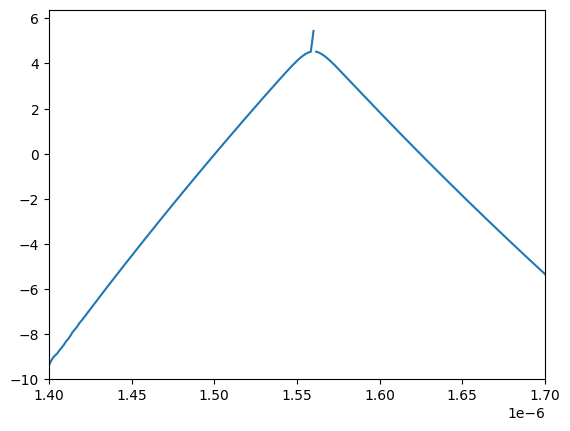

In [3]:
import jax
import jax.numpy as jnp

def LLE_operator(A):
    dispersion = jnp.fft.ifft( 1j * cavity_length * beta_2 / 2 * simulation.sim_omega ** 2 * jnp.fft.fft(A) )
    nonlinearity = 1j * gamma * cavity_length * jnp.abs(A) ** 2 * A
    linear = ( - alpha - 1j * detuning ) * A + jnp.sqrt(coupling_ring_bus) * A_in
    return linear + nonlinearity + dispersion

def newton_raphson_python_range(n, A):
    As = [ A ]
    for _ in range(n):
        LLE_residual, LLE_jacobian = jax.vjp(LLE_operator, A)
        I = jnp.eye(simulation.time.size, dtype=complex)
        J = jax.vmap(LLE_jacobian)(I)[0]
        
        delta_A = jnp.linalg.solve(-J, LLE_residual)
        A = delta_A + A
        As.append(A)
    return As

As_list = newton_raphson_python_range(100, A_init)

maxes = [ np.max(np.abs(A)) for A in As_list ]
residuals = [ np.sum(np.abs(LLE_operator(A))) for A in As_list ]
plt.plot(residuals, 'r-')
plt.yscale('log')
plt.show()

plt.plot(simulation.wavelength, np.log10(np.abs(np.fft.fft(As_list[-1])) ** 2))
# plt.yscale('log')
plt.xlim(1400e-9,1700e-9)
plt.ylim(-10)

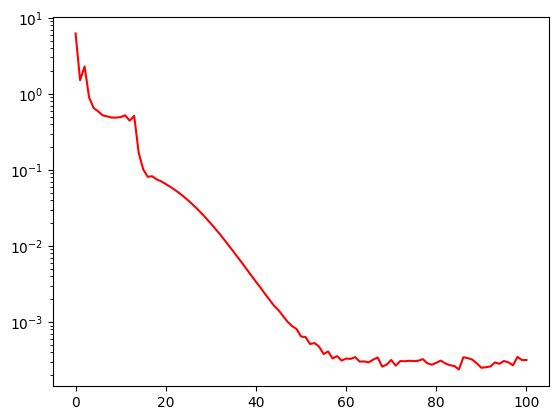

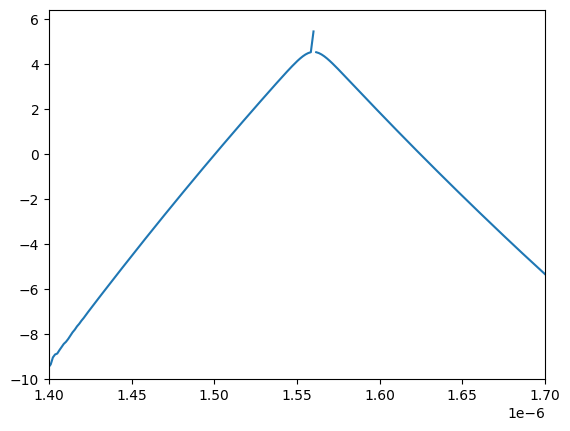

In [4]:
def newton_raphson_jax(n, A):
    def body_func(carry, ind):
        A = carry
        LLE_residual, LLE_jacobian = jax.vjp(LLE_operator, A)
        I = jnp.eye(simulation.time.size, dtype=complex)
        J = jax.vmap(LLE_jacobian)(I)[0]
        
        delta_A = jnp.linalg.solve(-J, LLE_residual)
        A = delta_A + A
        return A, A

    A_last, A_rest = jax.lax.scan(body_func, A, jnp.arange(n))
    return jnp.concat([A_init[None,...], A_rest], axis=0)
    
As_NR = newton_raphson_jax(100, A_init)

residuals = [ np.sum(np.abs(LLE_operator(A))) for A in As_NR ]
plt.plot(residuals, 'r-')
plt.yscale('log')
plt.show()

plt.plot(simulation.wavelength, np.log10(np.abs(np.fft.fft(As_NR[-1])) ** 2))
# plt.yscale('log')
plt.xlim(1400e-9,1700e-9)
plt.ylim(-10)

newton_raphson_jit = jax.jit(newton_raphson_jax, static_argnames=('n'))

In [16]:
len(error), len(As_pack)

(100, 100)

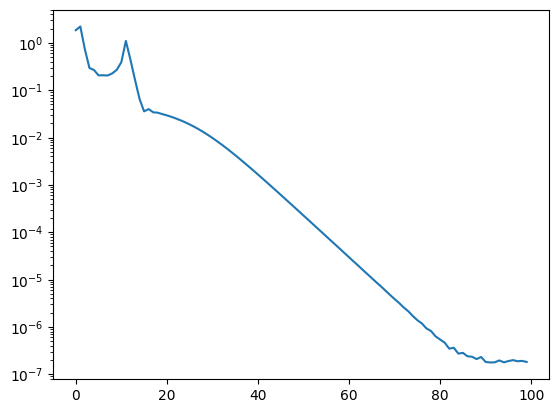

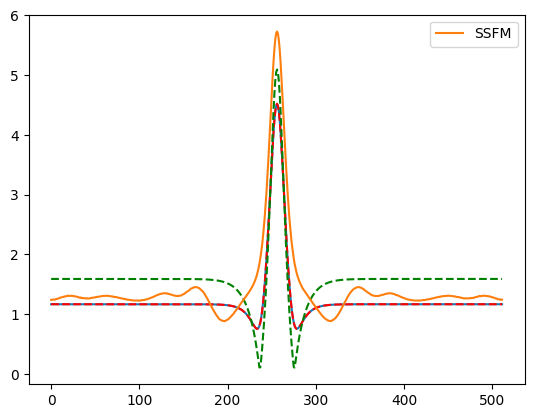

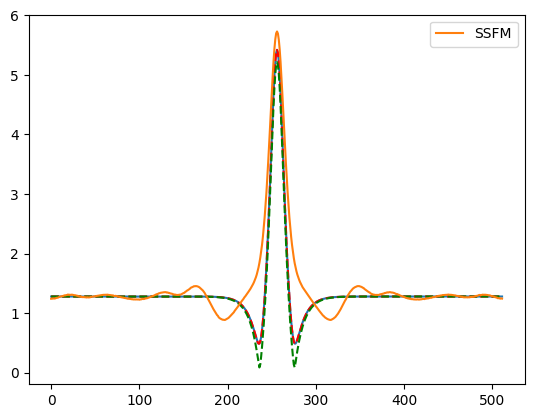

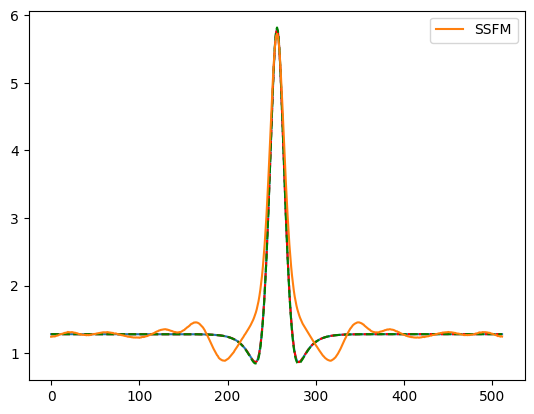

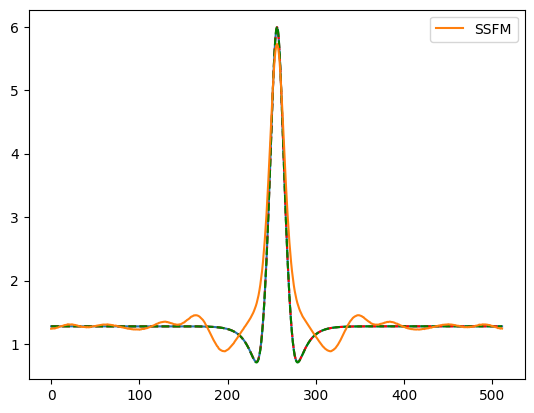

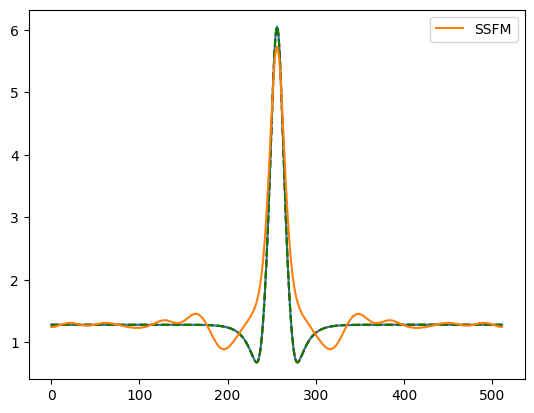

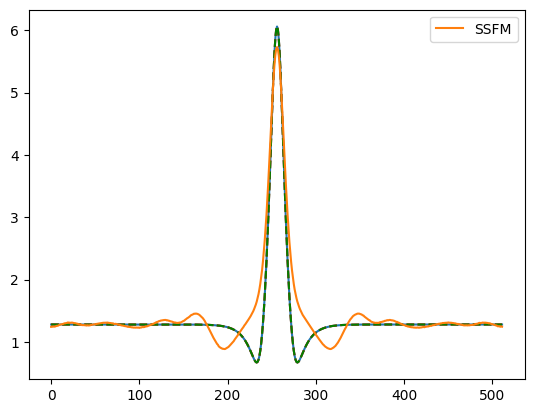

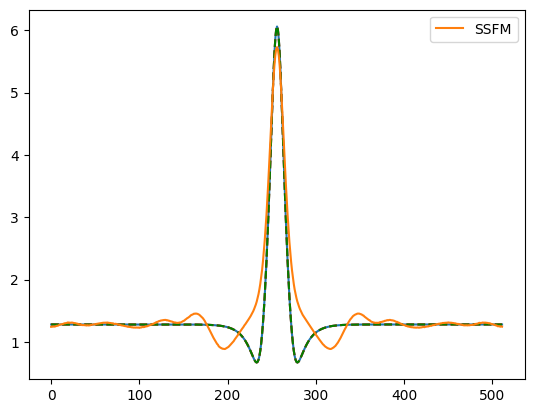

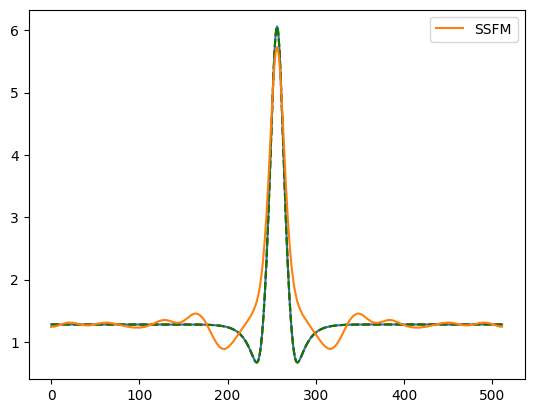

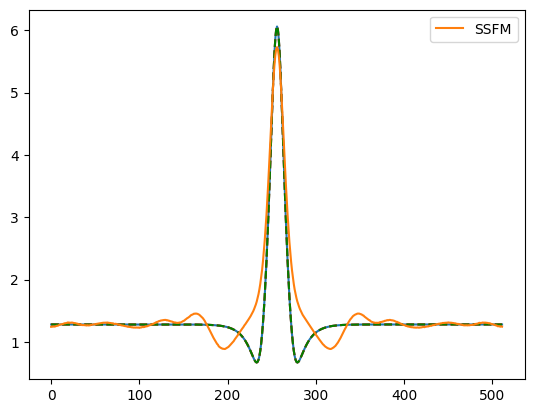

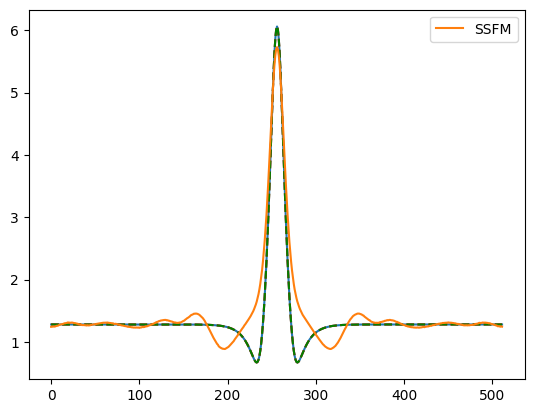

In [15]:
newton_raphson_solver = simulation.get_steady_state_solver()

As_pack, error = newton_raphson_solver(A_init, A_in, detuning, 100)
plt.plot(error)
plt.yscale('log')
plt.show()

for AL, ANR, AP in zip(As_list[::10], As_NR[::10], As_pack[::10]):
    plt.plot(np.abs(AL))
    plt.plot(np.abs(ANR), 'r--')
    plt.plot(np.abs(AP), 'g--')
    plt.plot(np.abs(A_main[-1]), label='SSFM')
    plt.legend()
    plt.show()

In [6]:
%timeit newton_raphson_python_range(10, A_init)
%timeit newton_raphson_jax(10, A_init)
%timeit newton_raphson_jit(10, A_init).block_until_ready()
%timeit newton_raphson_solver(A_init, A_in, detuning, 10).block_until_ready()

103 ms ± 4.08 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
128 ms ± 1.92 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
71.7 ms ± 3.34 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
75 ms ± 3.92 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
%timeit newton_raphson_python_range(100, A_init)
%timeit newton_raphson_jax(100, A_init)
%timeit newton_raphson_jit(100, A_init).block_until_ready()
%timeit newton_raphson_solver(A_init, A_in, detuning, 100).block_until_ready()

1.05 s ± 56.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
639 ms ± 20.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
642 ms ± 30.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
616 ms ± 29.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
